# Luck or skill? Goals vs expected goals in the Premier League

Are Premier League results a fair reflection of how well teams play? Expected goals (xG) measure the quality of the chances a team creates, so if a team scores more (or fewer) goals than its xG, the gap is either finishing skill or luck. If it is luck, it should not repeat from one season to the next, and we also check whether the picture is different at home and away.

## Data Collection

In [1]:
import io, time
from pathlib import Path
import numpy as np
import pandas as pd
import requests
from bs4 import BeautifulSoup
from scipy import stats
import statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import het_breuschpagan
import matplotlib.pyplot as plt
import seaborn as sns

# fixed seed so the bootstrap is reproducible
np.random.seed(42)
rng = np.random.default_rng(42)

DATA = Path("data")
RES = Path("results")
DATA.mkdir(exist_ok=True)
RES.mkdir(exist_ok=True)
RAW_FILE = DATA / "epl_matches_raw.csv"
USE_CACHED = True

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.dpi"] = 100
HOME, AWAY = "#2a78d6", "#eb6834"
OVER, UNDER = "#4a3aa7", "#e34948"
GREY = "#898781"

In [2]:
URL = "https://www.football-data.co.uk/"
HEADERS = {"User-Agent": "EPL luck-vs-skill student project (university data science course)"}
KEEP = ["Date", "HomeTeam", "AwayTeam", "FTHG", "FTAG", "FTR", "HxG", "AxG", "HS", "AS", "HST", "AST"]

def read_season(content):
    try:
        text = content.decode("utf-8-sig")
    except UnicodeDecodeError:
        text = content.decode("latin-1")
    # 2003-04 and 2004-05 have extra fields in some rows, so read with spare columns
    d = pd.read_csv(io.StringIO(text), header=None, names=range(200), dtype=str)
    d.columns = d.iloc[0].fillna("").str.replace("ï»¿", "").str.replace("\ufeff", "").str.strip()
    d = d.iloc[1:]
    return d[[c for c in KEEP if c in d.columns]]

if USE_CACHED and RAW_FILE.exists():
    raw = pd.read_csv(RAW_FILE, dtype=str)
    print("Loaded cached file", RAW_FILE, raw.shape)
else:
    # scrape the index page for all E0.csv links
    page = requests.get(URL + "englandm.php", headers=HEADERS, timeout=30)
    soup = BeautifulSoup(page.text, "html5lib")
    links = [a["href"] for a in soup.find_all("a", href=True) if a["href"].endswith("E0.csv")]
    print(len(links), "E0.csv links found, e.g.", links[:2])

    # download 2000-01 to 2025-26 (2026-27 is unfinished)
    frames = []
    for link in links:
        code = link.split("/")[-2]
        if not 0 <= int(code[:2]) <= 25:
            continue
        try:
            r = requests.get(URL + link, headers=HEADERS, timeout=30)
            r.raise_for_status()
            d = read_season(r.content)
            d["season"] = code
            frames.append(d)
            print(code, len(d), "rows")
        except Exception as e:
            print("failed to get", code, e)
        time.sleep(1)

    raw = pd.concat(frames, ignore_index=True)
    raw.to_csv(RAW_FILE, index=False)
    print("Saved", RAW_FILE, raw.shape)

Loaded cached file data\epl_matches_raw.csv (9881, 11)


In [3]:
# STEP 0: which seasons have xG?
cols = ["HxG", "AxG", "HS", "AS", "HST", "AST"]
for c in cols:
    if c not in raw.columns:
        raw[c] = np.nan
avail = raw.groupby("season")[cols].count()
print(avail.to_string())

xg_seasons = avail.index[(avail["HxG"] > 0) & (avail["AxG"] > 0)].tolist()
print("\nSeasons with xG:", xg_seasons if xg_seasons else "none")

if len(xg_seasons) == 0:
    PROXY = True
    print("No xG in any season 2000-01 to 2025-26 -> using shots on target (HST/AST) as the chance-quality proxy")
else:
    PROXY = False
    raw = raw[raw["season"].isin(xg_seasons)]
    print("Running the analysis on the xG seasons only:", xg_seasons)

        HxG  AxG   HS   AS  HST  AST
season                              
0001      0    0  380  380  380  380
0102      0    0  380  380  380  380
0203      0    0  380  380  380  380
0304      0    0  380  380  380  380
0405      0    0  380  380  380  380
0506      0    0  380  380  380  380
0607      0    0  380  380  380  380
0708      0    0  380  380  380  380
0809      0    0  380  380  380  380
0910      0    0  380  380  380  380
1011      0    0  380  380  380  380
1112      0    0  380  380  380  380
1213      0    0  380  380  380  380
1314      0    0  380  380  380  380
1415      0    0  380  380  380  380
1516      0    0  380  380  380  380
1617      0    0  380  380  380  380
1718      0    0  380  380  380  380
1819      0    0  380  380  380  380
1920      0    0  380  380  380  380
2021      0    0  380  380  380  380
2122      0    0  380  380  380  380
2223      0    0  380  380  380  380
2324      0    0  380  380  380  380
2425      0    0  380  380  380  380
2

## Cleaning

In [4]:
df = raw.copy()

df = df[[c for c in KEEP if c in df.columns] + ["season"]]
print("columns kept:", list(df.columns))

before = len(df)
df = df.dropna(subset=["HomeTeam", "AwayTeam", "FTR"])
print("blank rows dropped:", before - len(df))

for c in ["FTHG", "FTAG", "HxG", "AxG", "HS", "AS", "HST", "AST"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")
print("missing values after conversion:\n", df[["FTHG", "FTAG", "HS", "AS", "HST", "AST"]].isna().sum().to_dict())

# dates mix dd/mm/yy and dd/mm/yyyy
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True, format="mixed")
print("unparsed dates:", df["Date"].isna().sum(), "| range:", df["Date"].min().date(), "to", df["Date"].max().date())

columns kept: ['Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'HxG', 'AxG', 'HS', 'AS', 'HST', 'AST', 'season']
blank rows dropped: 1
missing values after conversion:
 {'FTHG': 0, 'FTAG': 0, 'HS': 0, 'AS': 0, 'HST': 0, 'AST': 0}
unparsed dates: 0 | range: 2000-08-19 to 2026-05-24


In [5]:
dups = df[df.duplicated(["Date", "HomeTeam", "AwayTeam"], keep=False)]
print("duplicate rows:", len(dups))
if len(dups):
    print(dups)
df = df.drop_duplicates(["Date", "HomeTeam", "AwayTeam"])

df["season_label"] = "20" + df["season"].str[:2] + "-" + df["season"].str[2:]

per_season = df.groupby("season_label").size()
print(per_season.to_string())
print("seasons not equal to 380:", per_season[per_season != 380].to_dict())

duplicate rows: 0
season_label
2000-01    380
2001-02    380
2002-03    380
2003-04    380
2004-05    380
2005-06    380
2006-07    380
2007-08    380
2008-09    380
2009-10    380
2010-11    380
2011-12    380
2012-13    380
2013-14    380
2014-15    380
2015-16    380
2016-17    380
2017-18    380
2018-19    380
2019-20    380
2020-21    380
2021-22    380
2022-23    380
2023-24    380
2024-25    380
2025-26    380
seasons not equal to 380: {}


In [6]:
teams = sorted(set(df["HomeTeam"]) | set(df["AwayTeam"]))
print(len(teams), "team names:", teams)
key = pd.Series(teams).str.lower().str.replace(r"[^a-z]", "", regex=True)
print("possible variants:", pd.Series(teams)[key.duplicated(keep=False)].tolist())

TEAM_FIX = {}
df["HomeTeam"] = df["HomeTeam"].replace(TEAM_FIX)
df["AwayTeam"] = df["AwayTeam"].replace(TEAM_FIX)
print("teams per season (expect 20):", df.groupby("season")["HomeTeam"].nunique().unique())

46 team names: ['Arsenal', 'Aston Villa', 'Birmingham', 'Blackburn', 'Blackpool', 'Bolton', 'Bournemouth', 'Bradford', 'Brentford', 'Brighton', 'Burnley', 'Cardiff', 'Charlton', 'Chelsea', 'Coventry', 'Crystal Palace', 'Derby', 'Everton', 'Fulham', 'Huddersfield', 'Hull', 'Ipswich', 'Leeds', 'Leicester', 'Liverpool', 'Luton', 'Man City', 'Man United', 'Middlesbrough', 'Newcastle', 'Norwich', "Nott'm Forest", 'Portsmouth', 'QPR', 'Reading', 'Sheffield United', 'Southampton', 'Stoke', 'Sunderland', 'Swansea', 'Tottenham', 'Watford', 'West Brom', 'West Ham', 'Wigan', 'Wolves']
possible variants: []
teams per season (expect 20): [20]


In [7]:
chk = df.groupby("season_label")[["HS", "AS", "HST", "AST"]].sum()
chk["shots_per_match"] = (chk["HS"] + chk["AS"]) / per_season
chk["share_on_target"] = (chk["HST"] + chk["AST"]) / (chk["HS"] + chk["AS"])
print(chk[["shots_per_match", "share_on_target"]].round(3).to_string())

# biggest drop in on-target share = the site changed how it counts shots on target
first = chk["share_on_target"].diff().idxmin()
print(f"\nBiggest drop in on-target share: {first} "
      f"({chk['share_on_target'].shift().loc[first]:.0%} -> {chk.loc[first, 'share_on_target']:.0%}), "
      "while shots per match stay about the same")
if PROXY:
    df = df[df["season_label"] >= first]
    print("Using", df["season_label"].nunique(), "seasons:", df["season_label"].min(), "to",
          df["season_label"].max(), "|", len(df), "matches")

              shots_per_match  share_on_target
season_label                                  
2000-01                22.171            0.482
2001-02                21.476            0.473
2002-03                22.421            0.529
2003-04                23.179            0.542
2004-05                22.213            0.530
2005-06                21.561            0.519
2006-07                22.508            0.509
2007-08                23.113            0.540
2008-09                24.358            0.540
2009-10                24.447            0.558
2010-11                24.866            0.547
2011-12                25.968            0.565
2012-13                25.137            0.566
2013-14                26.879            0.332
2014-15                25.911            0.324
2015-16                25.708            0.331
2016-17                25.497            0.340
2017-18                24.447            0.343
2018-19                25.279            0.344
2019-20      

In [8]:
# proxy xG = shots on target x league goals per shot on target
if PROXY:
    CONV = (df["FTHG"].sum() + df["FTAG"].sum()) / (df["HST"].sum() + df["AST"].sum())
    df["HxG"] = df["HST"] * CONV
    df["AxG"] = df["AST"] * CONV
    print(f"Proxy xG = shots on target x {CONV:.3f} (league goals per shot on target)")
print("rows with no chance-quality value:", df[["HxG", "AxG"]].isna().any(axis=1).sum())

Proxy xG = shots on target x 0.320 (league goals per shot on target)
rows with no chance-quality value: 0


In [9]:
# TEAM-MATCH table: home and away rows stacked
home = pd.DataFrame({"season": df["season_label"], "date": df["Date"], "team": df["HomeTeam"],
                     "venue": "Home", "goals_for": df["FTHG"], "goals_against": df["FTAG"],
                     "xg_for": df["HxG"], "xg_against": df["AxG"]})
away = pd.DataFrame({"season": df["season_label"], "date": df["Date"], "team": df["AwayTeam"],
                     "venue": "Away", "goals_for": df["FTAG"], "goals_against": df["FTHG"],
                     "xg_for": df["AxG"], "xg_against": df["HxG"]})
tm = pd.concat([home, away], ignore_index=True)
tm["g_xg"] = tm["goals_for"] - tm["xg_for"]
tm["points"] = np.where(tm["goals_for"] > tm["goals_against"], 3,
               np.where(tm["goals_for"] == tm["goals_against"], 1, 0))
print("team-match rows:", len(tm), "(should be 2 x matches =", 2 * len(df), ")")
tm.head()

team-match rows: 9880 (should be 2 x matches = 9880 )


,season,date,team,venue,goals_for,goals_against,xg_for,xg_against,g_xg,points
0,2025-26,2025-08-15,Liverpool,Home,4,2,3.198464,0.959539,0.801536,3
1,2025-26,2025-08-16,Aston Villa,Home,0,0,0.959539,0.959539,-0.959539,1
2,2025-26,2025-08-16,Brighton,Home,1,1,1.279386,0.639693,-0.279386,1
3,2025-26,2025-08-16,Sunderland,Home,3,0,1.599232,1.279386,1.400768,3
4,2025-26,2025-08-16,Tottenham,Home,3,0,1.919078,1.279386,1.080922,3


In [10]:
# TEAM-SEASON table, split by venue
ts = tm.groupby(["season", "team"]).agg(matches=("points", "size"), goals=("goals_for", "sum"),
                                        xg=("xg_for", "sum"), goals_against=("goals_against", "sum"),
                                        xg_against=("xg_against", "sum"), points=("points", "sum")).reset_index()
ts["g_xg"] = ts["goals"] - ts["xg"]
ts["gd"] = ts["goals"] - ts["goals_against"]
ts["xgd"] = ts["xg"] - ts["xg_against"]

venue = tm.pivot_table(index=["season", "team"], columns="venue",
                       values=["goals_for", "xg_for"], aggfunc="sum")
venue.columns = [f"{v.lower()}_{'goals' if c == 'goals_for' else 'xg'}" for c, v in venue.columns]
ts = ts.merge(venue.reset_index(), on=["season", "team"])
ts["home_g_xg"] = ts["home_goals"] - ts["home_xg"]
ts["away_g_xg"] = ts["away_goals"] - ts["away_xg"]
print("team-seasons:", len(ts), "| matches per team-season:", ts["matches"].unique())
ts.head()

team-seasons: 260 | matches per team-season: [38]


,season,team,matches,goals,xg,goals_against,xg_against,points,g_xg,gd,xgd,away_goals,home_goals,away_xg,home_xg,home_g_xg,away_g_xg
0,2013-14,Arsenal,38,68,67.167742,41,49.576191,79,0.832258,27,17.591552,32,36,30.705254,36.462489,-0.462489,1.294746
1,2013-14,Aston Villa,38,39,42.859417,61,54.054040,38,-3.859417,-22,-11.194624,17,22,18.870937,23.988479,-1.988479,-1.870937
2,2013-14,Cardiff,38,32,40.300645,74,74.204363,30,-8.300645,-42,-33.903718,12,20,16.632012,23.668633,-3.668633,-4.632012
3,2013-14,Chelsea,38,71,72.924977,27,39.660953,82,-1.924977,44,33.264025,28,43,29.745714,43.179263,-0.179263,-1.745714
4,2013-14,Crystal Palace,38,33,45.738034,48,53.734194,45,-12.738034,-15,-7.996160,15,18,21.429708,24.308326,-6.308326,-6.429708


## Analysis 1: Wrangling and descriptive statistics

In [11]:
df["total_goals"] = df["FTHG"] + df["FTAG"]
df["total_xg"] = df["HxG"] + df["AxG"]
league = df.groupby("season_label").agg(goals=("total_goals", "mean"), xg=("total_xg", "mean"))
league["goals_minus_xg"] = league["goals"] - league["xg"]
print(league.round(2).to_string())
print(f"\nAll seasons: {league['goals'].mean():.2f} goals vs {league['xg'].mean():.2f} xG per match")
print("Highest goals-minus-xG season:", league["goals_minus_xg"].idxmax(), round(league["goals_minus_xg"].max(), 2))
print("Lowest goals-minus-xG season:", league["goals_minus_xg"].idxmin(), round(league["goals_minus_xg"].min(), 2))

              goals    xg  goals_minus_xg
season_label                             
2013-14        2.77  2.85           -0.09
2014-15        2.57  2.69           -0.12
2015-16        2.70  2.72           -0.02
2016-17        2.80  2.77            0.03
2017-18        2.68  2.69           -0.01
2018-19        2.82  2.79            0.04
2019-20        2.72  2.73           -0.01
2020-21        2.69  2.76           -0.07
2021-22        2.82  2.82           -0.00
2022-23        2.85  2.82            0.04
2023-24        3.28  3.16            0.12
2024-25        2.93  2.91            0.02
2025-26        2.75  2.68            0.07

All seasons: 2.80 goals vs 2.80 xG per match
Highest goals-minus-xG season: 2023-24 0.12
Lowest goals-minus-xG season: 2014-15 -0.12


In [12]:
show = ["season", "team", "goals", "xg", "g_xg", "points"]
top5 = ts.nlargest(5, "g_xg")[show]
bottom5 = ts.nsmallest(5, "g_xg")[show]
print("Top 5 over-performers:\n", top5.round(1).to_string(index=False))
print("\nTop 5 under-performers:\n", bottom5.round(1).to_string(index=False))

Top 5 over-performers:
  season     team  goals   xg  g_xg  points
2013-14 Man City    102 76.1  25.9      86
2022-23 Man City     94 70.0  24.0      89
2022-23  Arsenal     88 65.2  22.8      84
2017-18 Man City    106 83.5  22.5     100
2016-17  Chelsea     85 65.2  19.8      93

Top 5 under-performers:
  season        team  goals   xg  g_xg  points
2013-14     Norwich     28 46.7 -18.7      33
2020-21      Fulham     27 43.5 -16.5      28
2016-17 Southampton     41 57.3 -16.3      46
2019-20     Norwich     26 41.9 -15.9      21
2013-14   Newcastle     43 58.9 -15.9      49


In [13]:
ha = tm.groupby("venue")[["xg_for", "goals_for", "g_xg"]].mean().loc[["Home", "Away"]]
ha["goals_per_xg"] = ha["goals_for"] / ha["xg_for"]
print(ha.round(3).to_string())
print(f"\nHome teams create {ha.loc['Home','xg_for'] / ha.loc['Away','xg_for']:.2f}x the xG of away teams "
      f"and score {ha.loc['Home','goals_for'] / ha.loc['Away','goals_for']:.2f}x the goals")

       xg_for  goals_for   g_xg  goals_per_xg
venue                                        
Home    1.527      1.546  0.018         1.012
Away    1.272      1.253 -0.018         0.986

Home teams create 1.20x the xG of away teams and score 1.23x the goals


No real xG on the site for these seasons, so xG here = shots on target × 0.320 (13 seasons, 2013-14 to 2025-26, 4,940 matches).
As a league, teams score exactly what their chances say (2.80 goals vs 2.80 xG per match), but single teams can be way off: Man City 2013-14 scored 102 from 76.1 xG (+25.9), Norwich 2013-14 only 28 from 46.7 (-18.7).

## Analysis 2: Visualization

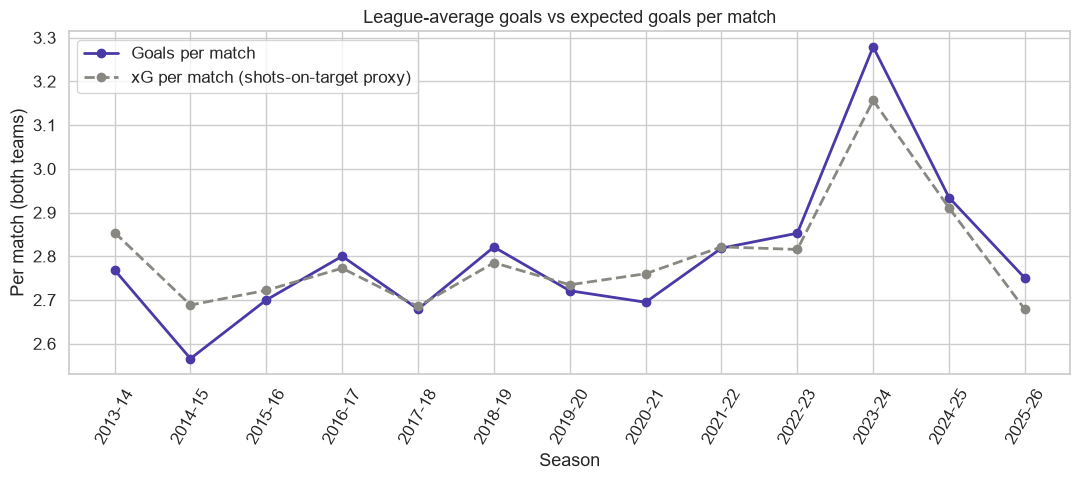

In [14]:
# Graph 1: league-average goals vs xG per match, by season
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(league.index, league["goals"], marker="o", color=OVER, lw=2, label="Goals per match")
ax.plot(league.index, league["xg"], marker="o", color=GREY, lw=2, ls="--",
        label="xG per match" + (" (shots-on-target proxy)" if PROXY else ""))
ax.set_title("League-average goals vs expected goals per match")
ax.set_xlabel("Season")
ax.set_ylabel("Per match (both teams)")
ax.tick_params(axis="x", rotation=60)
ax.legend()
plt.tight_layout()
plt.savefig(RES / "01_intro_league_goals_vs_xg.png", dpi=200, bbox_inches="tight")
plt.show()

No lucky or unlucky seasons for the league as a whole: across 13 seasons, goals and xG never drift more than 0.12 per match apart (+0.12 in 2023-24, -0.12 in 2014-15).

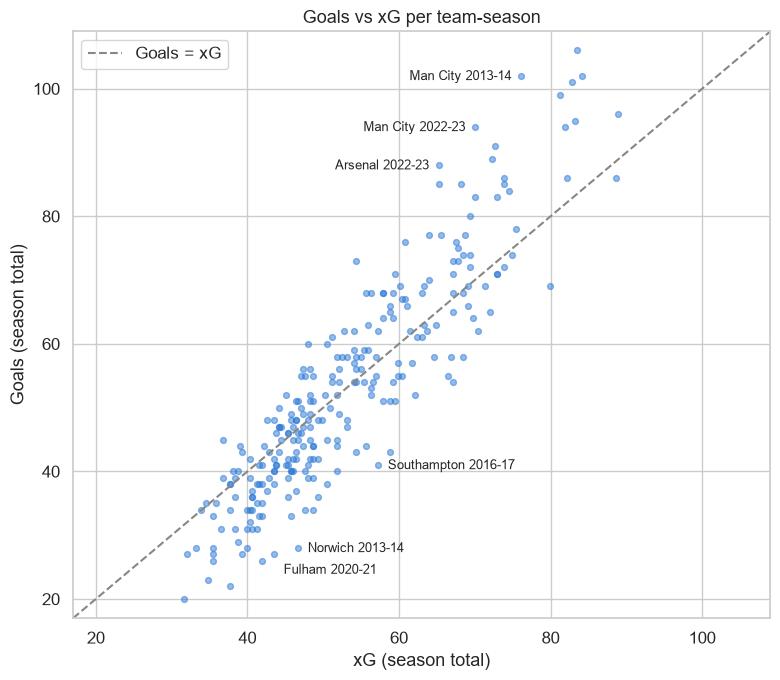

In [15]:
# Graph 2: goals vs xG for every team-season, with the 45-degree "fair" line
fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(ts["xg"], ts["goals"], s=18, alpha=0.5, color=HOME)
lims = [min(ts["xg"].min(), ts["goals"].min()) - 3, max(ts["xg"].max(), ts["goals"].max()) + 3]
ax.plot(lims, lims, color=GREY, ls="--", label="Goals = xG")
outliers = pd.concat([ts.nlargest(3, "g_xg"), ts.nsmallest(3, "g_xg")])
offsets = [(-7, -3), (-7, -3), (-7, -3), (7, -3), (7, -14), (7, -3)]
for (_, r), (dx, dy) in zip(outliers.iterrows(), offsets):
    ax.annotate(f"{r['team']} {r['season']}", (r["xg"], r["goals"]), fontsize=9,
                xytext=(dx, dy), textcoords="offset points", ha="right" if dx < 0 else "left")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_title("Goals vs xG per team-season")
ax.set_xlabel("xG (season total)")
ax.set_ylabel("Goals (season total)")
ax.legend()
plt.tight_layout()
plt.savefig(RES / "02_goals_vs_xg_scatter.png", dpi=200, bbox_inches="tight")
plt.show()

Across 260 team-seasons, goals mostly follow the chances created, but a few end up far off: Man City 2013-14 scored 102 from 76.1 xG, Fulham 2020-21 only 27 from 43.5.

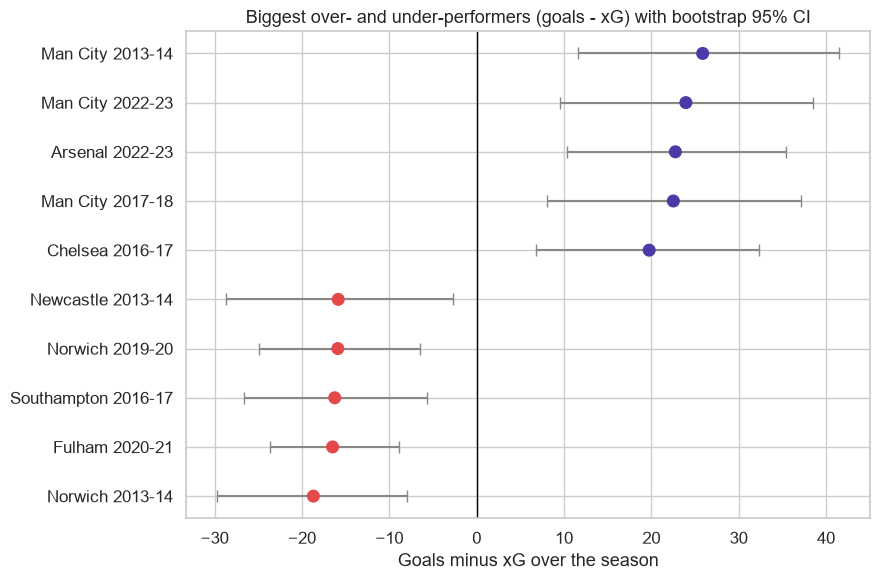

 season        team  g_xg  ci_low  ci_high
2013-14    Man City  25.9    11.6     41.5
2022-23    Man City  24.0     9.6     38.5
2022-23     Arsenal  22.8    10.4     35.4
2017-18    Man City  22.5     8.0     37.2
2016-17     Chelsea  19.8     6.8     32.4
2013-14   Newcastle -15.9   -28.7     -2.7
2019-20     Norwich -15.9   -24.9     -6.5
2016-17 Southampton -16.3   -26.7     -5.7
2020-21      Fulham -16.5   -23.6     -8.9
2013-14     Norwich -18.7   -29.7     -8.0


In [16]:
# bootstrap 95% CI of goals - xG for every team-season (10,000 resamples)
def boot_ci(x, n=10_000):
    x = np.asarray(x)
    sums = x[rng.integers(0, len(x), size=(n, len(x)))].sum(axis=1)
    return np.percentile(sums, [2.5, 97.5])

ci = tm.groupby(["season", "team"])["g_xg"].apply(boot_ci)
ts["ci_low"] = [ci[(s, t)][0] for s, t in zip(ts["season"], ts["team"])]
ts["ci_high"] = [ci[(s, t)][1] for s, t in zip(ts["season"], ts["team"])]

# Graph 3: top 5 over- and under-performers with their bootstrap CI
best = pd.concat([ts.nlargest(5, "g_xg"), ts.nsmallest(5, "g_xg").iloc[::-1]])
best = best.iloc[::-1]
labels = best["team"] + " " + best["season"]
colors = [OVER if v > 0 else UNDER for v in best["g_xg"]]
fig, ax = plt.subplots(figsize=(9, 6))
ax.errorbar(best["g_xg"], range(len(best)), xerr=[best["g_xg"] - best["ci_low"], best["ci_high"] - best["g_xg"]],
            fmt="none", ecolor=GREY, capsize=4, lw=1.5)
ax.scatter(best["g_xg"], range(len(best)), color=colors, s=70, zorder=3)
ax.axvline(0, color="black", lw=1)
ax.set_yticks(range(len(best)))
ax.set_yticklabels(labels)
ax.set_title("Biggest over- and under-performers (goals - xG) with bootstrap 95% CI")
ax.set_xlabel("Goals minus xG over the season")
plt.tight_layout()
plt.savefig(RES / "03_over_under_performers.png", dpi=200, bbox_inches="tight")
plt.show()
print(best.iloc[::-1][["season", "team", "g_xg", "ci_low", "ci_high"]].round(1).to_string(index=False))

The top 5 over- and under-performers (Man City 2013-14 +25.9 down to Norwich 2013-14 -18.7) are real for that season, since none of their 95% CIs include zero.

But the exact size is pretty uncertain, e.g. Man City 2013-14 could be anywhere from +11.6 to +41.5.

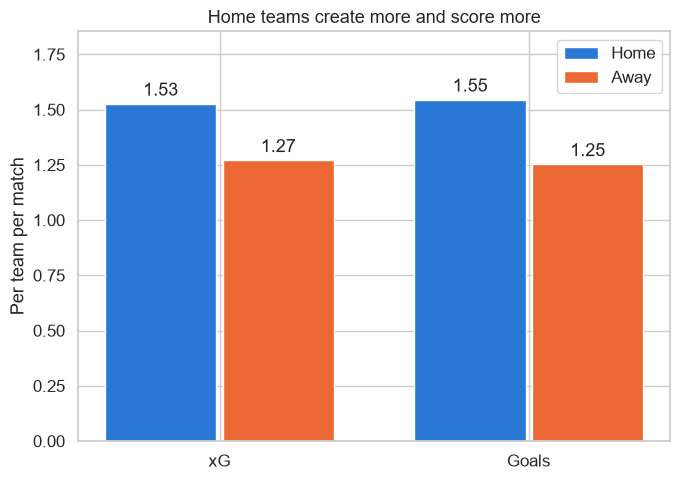

In [17]:
# Graph 4: average xG and goals per team-match, home vs away
plot = ha[["xg_for", "goals_for"]].rename(columns={"xg_for": "xG", "goals_for": "Goals"})
x = np.arange(2)
fig, ax = plt.subplots(figsize=(7, 5))
for i, (v, col) in enumerate([("Home", HOME), ("Away", AWAY)]):
    bars = ax.bar(x + (i - 0.5) * 0.38, plot.loc[v], width=0.36, color=col, label=v)
    ax.bar_label(bars, fmt="%.2f", padding=3)
ax.set_xticks(x)
ax.set_xticklabels(plot.columns)
ax.set_ylim(0, plot.values.max() * 1.2)
ax.set_ylabel("Per team per match")
ax.set_title("Home teams create more and score more")
ax.legend()
plt.tight_layout()
plt.savefig(RES / "04_home_away_xg_goals.png", dpi=200, bbox_inches="tight")
plt.show()

Home teams score more mainly because they create more: 1.53 vs 1.27 xG and 1.55 vs 1.25 goals per match (about +0.26 xG and +0.29 goals).

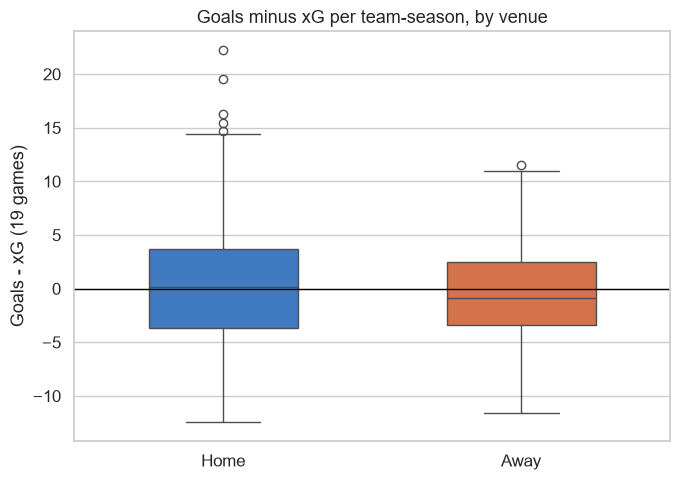

       count  mean   std    min   25%   50%   75%    max
Venue                                                   
Away   260.0 -0.35  4.54 -11.55 -3.43 -0.83  2.49  11.54
Home   260.0  0.35  5.74 -12.47 -3.64  0.13  3.68  22.26


In [18]:
# Graph 5: goals - xG per team-season, home games vs away games
long = pd.DataFrame({"Venue": ["Home"] * len(ts) + ["Away"] * len(ts),
                     "g_xg": pd.concat([ts["home_g_xg"], ts["away_g_xg"]], ignore_index=True)})
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=long, x="Venue", y="g_xg", hue="Venue", palette={"Home": HOME, "Away": AWAY},
            width=0.5, legend=False, ax=ax)
ax.axhline(0, color="black", lw=1)
ax.set_title("Goals minus xG per team-season, by venue")
ax.set_xlabel("")
ax.set_ylabel("Goals - xG (19 games)")
plt.tight_layout()
plt.savefig(RES / "05_gxg_by_venue_boxplot.png", dpi=200, bbox_inches="tight")
plt.show()
print(long.groupby("Venue")["g_xg"].describe().round(2))

Over 260 team-seasons, teams finish roughly in line with their xG both home and away (median +0.13 vs -0.83), so venue doesn't change finishing much; home is just a bit more spread out (SD 5.74 vs 4.54).

## Analysis 3: Correlation and linear regression

In [19]:
# goals ~ xG regression, home and away separately
models = {}
for v in ["Home", "Away"]:
    m = smf.ols("goals_for ~ xg_for", data=tm[tm["venue"] == v]).fit()
    models[v] = m
    lo, hi = m.conf_int().loc["xg_for"]
    r = stats.pearsonr(tm.loc[tm["venue"] == v, "xg_for"], tm.loc[tm["venue"] == v, "goals_for"])[0]
    print(f"{v}: goals = {m.params['Intercept']:.3f} + {m.params['xg_for']:.3f} x xG  "
          f"(slope 95% CI {lo:.3f} to {hi:.3f}), R2 = {m.rsquared:.3f}, r = {r:.3f}, n = {int(m.nobs)}")

# slope difference test (interaction term)
inter = smf.ols("goals_for ~ xg_for * C(venue)", data=tm).fit()
print("\nSlope difference (home vs away) p-value:", round(inter.pvalues["xg_for:C(venue)[T.Home]"], 4))

for v, m in models.items():
    bp = het_breuschpagan(m.resid, m.model.exog)[1]
    print(f"{v} residuals: mean {m.resid.mean():.3f}, skew {stats.skew(m.resid):.2f}, "
          f"Breusch-Pagan p = {bp:.3g} (small p = spread grows with xG)")

Home: goals = 0.130 + 0.927 x xG  (slope 95% CI 0.891 to 0.962), R2 = 0.349, r = 0.590, n = 4940
Away: goals = 0.028 + 0.964 x xG  (slope 95% CI 0.928 to 1.000), R2 = 0.356, r = 0.597, n = 4940

Slope difference (home vs away) p-value: 0.1546
Home residuals: mean 0.000, skew 0.40, Breusch-Pagan p = 3.31e-115 (small p = spread grows with xG)
Away residuals: mean -0.000, skew 0.45, Breusch-Pagan p = 1.19e-128 (small p = spread grows with xG)


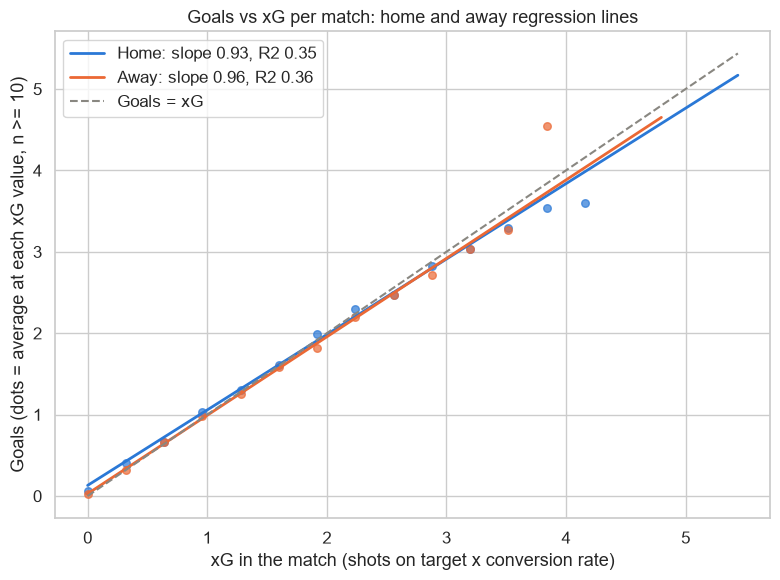

In [20]:
# Graph 6: goals vs xG with the home and away regression lines
fig, ax = plt.subplots(figsize=(8, 6))
for v, col in [("Home", HOME), ("Away", AWAY)]:
    sub = tm[tm["venue"] == v]
    means = sub.groupby("xg_for")["goals_for"].agg(["mean", "size"])
    means = means[means["size"] >= 10]
    ax.scatter(means.index, means["mean"], color=col, s=30, alpha=0.7)
    m = models[v]
    xs = np.linspace(0, sub["xg_for"].max(), 50)
    ax.plot(xs, m.params["Intercept"] + m.params["xg_for"] * xs, color=col, lw=2,
            label=f"{v}: slope {m.params['xg_for']:.2f}, R2 {m.rsquared:.2f}")
ax.plot([0, tm["xg_for"].max()], [0, tm["xg_for"].max()], color=GREY, ls="--", label="Goals = xG")
ax.set_title("Goals vs xG per match: home and away regression lines")
ax.set_xlabel("xG in the match" + (" (shots on target x conversion rate)" if PROXY else ""))
ax.set_ylabel("Goals (dots = average at each xG value, n >= 10)")
ax.legend()
plt.tight_layout()
plt.savefig(RES / "06_regression_home_away.png", dpi=200, bbox_inches="tight")
plt.show()

Over 4,940 matches per venue, xG predicts goals the same way home and away (slope 0.93 vs 0.96, p = 0.15), but one match is noisy: xG only explains about 35% of the goals (R2 0.35 vs 0.36).

points ~ xgd: slope 0.770 points per goal, R2 = 0.797
points ~ gd: slope 0.626 points per goal, R2 = 0.934


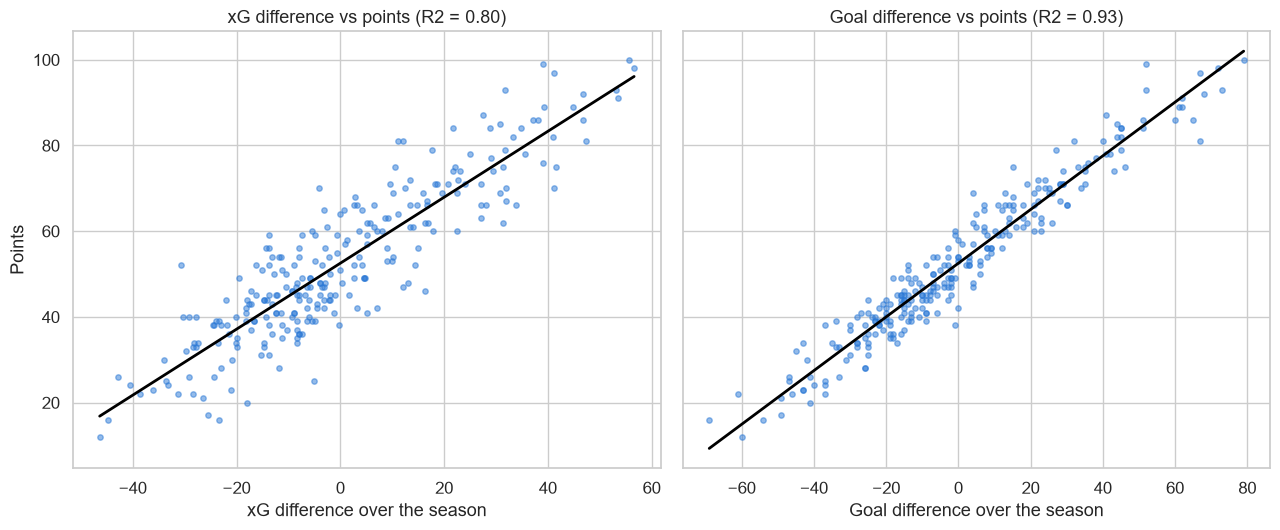

In [21]:
# points ~ xG difference vs points ~ goal difference
fits = {}
for col in ["xgd", "gd"]:
    m = smf.ols(f"points ~ {col}", data=ts).fit()
    fits[col] = m
    print(f"points ~ {col}: slope {m.params[col]:.3f} points per goal, R2 = {m.rsquared:.3f}")

# Graph 7: two panels
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharey=True)
for ax, col, name in [(axes[0], "xgd", "xG difference"), (axes[1], "gd", "Goal difference")]:
    m = fits[col]
    ax.scatter(ts[col], ts["points"], s=15, alpha=0.5, color=HOME)
    xs = np.linspace(ts[col].min(), ts[col].max(), 50)
    ax.plot(xs, m.params["Intercept"] + m.params[col] * xs, color="black", lw=2)
    ax.set_title(f"{name} vs points (R2 = {m.rsquared:.2f})")
    ax.set_xlabel(f"{name} over the season")
axes[0].set_ylabel("Points")
plt.tight_layout()
plt.savefig(RES / "07_xg_vs_goal_diff_points.png", dpi=200, bbox_inches="tight")
plt.show()

Over 260 team-seasons, chances explain most of the league table (R2 0.80 for xG difference), but actual goals explain even more (R2 0.93 for goal difference).

## Analysis 4: Hypothesis testing and resampling

In [22]:
# (a) paired t-test: goals vs xG
for name, sub in [("All", tm), ("Home", tm[tm["venue"] == "Home"]), ("Away", tm[tm["venue"] == "Away"])]:
    t, p = stats.ttest_rel(sub["goals_for"], sub["xg_for"])
    print(f"{name}: mean goals - xG = {sub['g_xg'].mean():+.3f} per match, t = {t:.2f}, p = {p:.3g}, n = {len(sub)}")
if PROXY:
    print("(The 'All' mean is zero by construction: the proxy rate was set from the same goals and shots.)")

All: mean goals - xG = -0.000 per match, t = -0.00, p = 1, n = 9880
Home: mean goals - xG = +0.018 per match, t = 1.22, p = 0.223, n = 4940
Away: mean goals - xG = -0.018 per match, t = -1.35, p = 0.178, n = 4940
(The 'All' mean is zero by construction: the proxy rate was set from the same goals and shots.)


In [23]:
# (b) home xG vs away xG (one-sided)
t, p = stats.ttest_rel(df["HxG"], df["AxG"], alternative="greater")
diff = df["HxG"] - df["AxG"]
print(f"Home xG - away xG = {diff.mean():+.3f} per match, t = {t:.2f}, one-sided p = {p:.3g}, "
      f"effect size dz = {diff.mean() / diff.std():.2f}")

# (c) home vs away conversion (goals per xG)
ts["home_conv"] = ts["home_goals"] / ts["home_xg"]
ts["away_conv"] = ts["away_goals"] / ts["away_xg"]
t, p = stats.ttest_rel(ts["home_conv"], ts["away_conv"])
w = stats.wilcoxon(ts["home_conv"], ts["away_conv"])
print(f"Goals per xG: home {ts['home_conv'].mean():.3f} vs away {ts['away_conv'].mean():.3f}, "
      f"paired t p = {p:.3g}, Wilcoxon p = {w.pvalue:.3g}, n = {len(ts)} team-seasons")

Home xG - away xG = +0.256 per match, t = 14.64, one-sided p = 7.7e-48, effect size dz = 0.21
Goals per xG: home 1.000 vs away 0.970, paired t p = 0.0415, Wilcoxon p = 0.0629, n = 260 team-seasons


In [24]:
# (d) how many team-season CIs exclude 0?
outside = (ts["ci_low"] > 0) | (ts["ci_high"] < 0)
print(f"{outside.sum()} of {len(ts)} team-seasons ({outside.mean():.1%}) have a CI that excludes 0 "
      f"(about 5% would by pure chance)")
print(f"over: {(ts['ci_low'] > 0).sum()}, under: {(ts['ci_high'] < 0).sum()}")
print(f"typical (median) CI width: {(ts['ci_high'] - ts['ci_low']).median():.1f} goals over a season")

38 of 260 team-seasons (14.6%) have a CI that excludes 0 (about 5% would by pure chance)
over: 17, under: 21
typical (median) CI width: 23.2 goals over a season


Home teams win by creating more (+0.256 xG per match, p < 0.001), not by finishing better (goals minus xG +0.018 home, p = 0.22; -0.018 away, p = 0.18; conversion 1.00 vs 0.97, borderline at p = 0.04 / 0.06).

And 38 of 260 team-seasons (14.6%) are off their xG by more than luck would usually give (about 5% expected).

g_xg: Pearson r = 0.326 (p = 1.92e-06), Spearman rho = 0.286 (p = 3.4e-05), n = 204 pairs
home_g_xg: Pearson r = 0.261 (p = 0.000167), Spearman rho = 0.276 (p = 6.34e-05), n = 204 pairs
away_g_xg: Pearson r = 0.076 (p = 0.279), Spearman rho = 0.088 (p = 0.213), n = 204 pairs


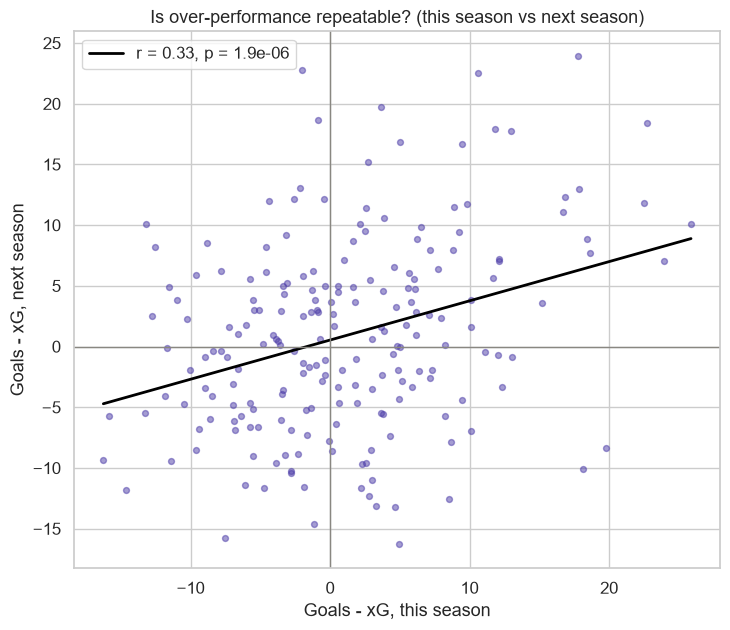

In [25]:
# (e) persistence: does goals - xG repeat?
seasons = sorted(ts["season"].unique())
if len(seasons) >= 3:
    nxt = ts[["season", "team", "g_xg", "home_g_xg", "away_g_xg"]].copy()
    nxt["season"] = nxt["season"].map({s: seasons[i - 1] for i, s in enumerate(seasons) if i > 0})
    pairs = ts.merge(nxt, on=["season", "team"], suffixes=("_1", "_2"))
    p1, p2 = "this season", "next season"
else:
    tm["half"] = np.where(tm.groupby(["season", "team"])["date"].rank(method="first") <= 19, 1, 2)
    h = tm.pivot_table(index=["season", "team", "venue"], columns="half", values="g_xg", aggfunc="sum")
    pairs = tm.pivot_table(index=["season", "team"], columns="half", values="g_xg", aggfunc="sum")
    pairs.columns = ["g_xg_1", "g_xg_2"]
    pairs = pairs.join(h.xs("Home", level="venue").set_axis(["home_g_xg_1", "home_g_xg_2"], axis=1))
    pairs = pairs.join(h.xs("Away", level="venue").set_axis(["away_g_xg_1", "away_g_xg_2"], axis=1)).reset_index()
    p1, p2 = "first half", "second half"

for c in ["g_xg", "home_g_xg", "away_g_xg"]:
    r, p = stats.pearsonr(pairs[c + "_1"], pairs[c + "_2"])
    rho, p_s = stats.spearmanr(pairs[c + "_1"], pairs[c + "_2"])
    print(f"{c}: Pearson r = {r:.3f} (p = {p:.3g}), Spearman rho = {rho:.3f} (p = {p_s:.3g}), n = {len(pairs)} pairs")

# Graph 8: persistence scatter
r, p = stats.pearsonr(pairs["g_xg_1"], pairs["g_xg_2"])
slope, icpt = np.polyfit(pairs["g_xg_1"], pairs["g_xg_2"], 1)
fig, ax = plt.subplots(figsize=(7.5, 6.5))
ax.scatter(pairs["g_xg_1"], pairs["g_xg_2"], s=18, alpha=0.5, color=OVER)
xs = np.linspace(pairs["g_xg_1"].min(), pairs["g_xg_1"].max(), 50)
ax.plot(xs, icpt + slope * xs, color="black", lw=2, label=f"r = {r:.2f}, p = {p:.2g}")
ax.axhline(0, color=GREY, lw=1)
ax.axvline(0, color=GREY, lw=1)
ax.set_title(f"Is over-performance repeatable? ({p1} vs {p2})")
ax.set_xlabel(f"Goals - xG, {p1}")
ax.set_ylabel(f"Goals - xG, {p2}")
ax.legend()
plt.tight_layout()
plt.savefig(RES / "08_persistence.png", dpi=200, bbox_inches="tight")
plt.show()

Beating your xG is partly repeatable: across 204 team pairs it carries into next season (r = 0.33, p < 0.001), at home (r = 0.26) but not away (r = 0.08, p = 0.28).

## Robustness

In [26]:
# drop matches where a team scored 4+ and repeat the test
small = df[(df["FTHG"] < 4) & (df["FTAG"] < 4)].copy()
print(f"kept {len(small)} of {len(df)} matches ({len(df) - len(small)} dropped)")
if PROXY:
    conv2 = (small["FTHG"].sum() + small["FTAG"].sum()) / (small["HST"].sum() + small["AST"].sum())
    small["HxG"] = small["HST"] * conv2
    small["AxG"] = small["AST"] * conv2
    print(f"conversion rate on kept matches: {conv2:.3f} (full data {CONV:.3f})")

for name, g, x in [("Home", small["FTHG"], small["HxG"]), ("Away", small["FTAG"], small["AxG"])]:
    t, p = stats.ttest_rel(g, x)
    print(f"{name}: mean goals - xG = {(g - x).mean():+.3f} per match, t = {t:.2f}, p = {p:.3g}")

kept 4313 of 4940 matches (627 dropped)
conversion rate on kept matches: 0.289 (full data 0.320)
Home: mean goals - xG = -0.001 per match, t = -0.05, p = 0.964
Away: mean goals - xG = +0.001 per match, t = 0.05, p = 0.962


Dropping the 627 matches where a team scored 4+ (4,313 left) changes nothing: still no home vs away finishing difference (-0.001 vs +0.001 goals per match, both p = 0.96).

#### Conclusion

Results mostly follow chances (xG difference explains 80% of points), home teams win by creating more (+0.256 xG per match) rather than finishing better (p = 0.22), and 14.6% of team-seasons beat or miss xG by more than luck, which partly repeats (r = 0.33, mainly at home).
Limits: xG is a shots-on-target proxy, only 13 seasons are usable, and 38 games a season is noisy (a typical 95% CI is about 23 goals wide).